In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.special import erfcinv
import statsmodels.api as sm

In [94]:
def get_outliers_cooks(df):
    """
    Нахождение выбросов на основе расстояния Кука
    """
    # storing dependant values
    y = df.iloc[:, 1]

    # storing independent values
    x = df.iloc[:, 0]

    # add bias
    x = sm.add_constant(x)

    # create and train linear regression model
    sm_model = sm.regression.linear_model.OLS(y, x).fit()
    influence = sm_model.get_influence()

    influence_list = influence.cooks_distance[0]
    influence_df = pd.DataFrame(influence_list, columns=["influence"], index=df.index)

    original_length = len(df)

    cooks_df = df.join(influence_df)
    cooks_threshold = 4 / original_length
    cooks_outliers = cooks_df[cooks_df["influence"] > cooks_threshold]

    return set(cooks_outliers.index)

In [95]:
df = pd.read_csv('../data/result_main.csv')

In [96]:
df

,Factor,PTA right 250Hz AC,PTA right 500Hz AC,PTA right 1000Hz AC,PTA right 2000Hz AC,PTA right 4000Hz AC,PTA right 8000Hz AC,PTA left 250Hz AC,PTA left 500Hz AC,PTA left 1000Hz AC,...,"Monosyllabic speech HA in white noise FF, %",Patient's rating about HA effeciency : 1 - very bad; 5 excellent,"Predicted Multisyllabic speech without HA in quiet FF, %","Predicted Multisyllabic speech with HA in quiet FF, %","Predicted Multisyllabic speech without HA in babble noise FF, %","Predicted Multisyllabic speech with HA in white noise FF, %","Predicted Multisyllabic speech with HA in babble noise FF, %","Predicted Monosyllabic speech HA in quiet FF, %","Predicted Monosyllabic speech HA in white noise FF, %",Predicted Patient's rating about HA effeciency : 1 - very bad; 5 excellent
0,1,NaN,35.0,40.0,55.0,70.0,NaN,NaN,30.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,120.0,120.0,120.0,120.0,NaN,NaN,75.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,40.0,50.0,50.0,70.0,NaN,NaN,35.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,50.0,50.0,50.0,60.0,NaN,NaN,55.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,30.0,45.0,45.0,45.0,NaN,NaN,50.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,490,30.0,50.0,55.0,40.0,40.0,65.0,35.0,45.0,50.0,...,NaN,NaN,48.947975,63.515625,22.533985,94.972453,52.699701,83.398926,94.428261,4.893641
490,491,30.0,35.0,35.0,55.0,65.0,80.0,90.0,90.0,75.0,...,NaN,NaN,82.090843,77.098897,59.067706,85.397327,67.763708,52.610463,73.696460,4.356820
491,492,50.0,50.0,55.0,50.0,45.0,50.0,50.0,50.0,60.0,...,NaN,NaN,89.534255,64.553236,77.975104,79.085334,77.622709,71.191165,64.363458,4.619840
492,493,45.0,40.0,50.0,50.0,40.0,35.0,45.0,40.0,45.0,...,NaN,NaN,67.312782,44.970621,62.067199,89.530774,40.669347,69.130216,80.265761,4.533672


In [97]:
# k1 = 'Multisyllabic speech without HA in quiet FF, %' 
# k2 = 'Multisyllabic speech with HA in quiet FF, %'
# p1 = 'Predicted Multisyllabic speech without HA in quiet FF, %' 
# p2 = 'Predicted Multisyllabic speech with HA in quiet FF, %'

In [98]:
# df1 = df[[k1, p1]]

In [99]:
# out = get_outliers_cooks(df1.dropna())

# df_drop_out1 = df[~df.index.isin(out)]

# df_drop_out1 = df_drop_out1.dropna()

In [100]:
# b, a = np.polyfit(df_drop_out[k1], df_drop_out[p1], deg=1)

In [101]:
# yn = np.poly1d([b, a])

In [102]:
# df_drop_out['predict_lin'] = yn(df_drop_out[k1])

In [103]:
# xseq = np.linspace(df[p1].min()-5, df[p1].max()+5, num=100)

In [104]:
# plt.plot(xseq, a + b * xseq, lw=1)

In [105]:
# df_drop_out['error'] = df_drop_out[p1] - df_drop_out['predict_lin']

In [106]:
# df_drop_out['error'].hist()

In [107]:
# cols = [k2, p2]
# color_dict = {k2: 'tab:blue', p2: 'tab:orange'}

In [108]:
# column_name1 = 'Multisyllabic speech without HA in quiet FF, %' 
# column_name2 = 'Multisyllabic speech with HA in quiet FF, %'

In [109]:
# column_name1 = 'Multisyllabic speech with HA in quiet FF, %'
# column_name2 = 'Monosyllabic speech HA in quiet FF, %'

In [127]:
# column_name1 = 'Multisyllabic speech with HA in quiet FF, %'
# column_name2 = 'Multisyllabic speech with HA in babble noise FF, %'

In [169]:
# column_name1 = 'Multisyllabic speech without HA in quiet FF, %'
# column_name2 = 'Multisyllabic speech without HA in babble noise FF, %'

In [194]:
# column_name1 = 'Multisyllabic speech with HA in white noise FF, %'
# column_name2 = 'Monosyllabic speech HA in white noise FF, %'

In [219]:
column_name1 = 'Monosyllabic speech HA in quiet FF, %'
column_name2 = 'Monosyllabic speech HA in white noise FF, %'

In [220]:
df

,Factor,PTA right 250Hz AC,PTA right 500Hz AC,PTA right 1000Hz AC,PTA right 2000Hz AC,PTA right 4000Hz AC,PTA right 8000Hz AC,PTA left 250Hz AC,PTA left 500Hz AC,PTA left 1000Hz AC,...,"Monosyllabic speech HA in white noise FF, %",Patient's rating about HA effeciency : 1 - very bad; 5 excellent,"Predicted Multisyllabic speech without HA in quiet FF, %","Predicted Multisyllabic speech with HA in quiet FF, %","Predicted Multisyllabic speech without HA in babble noise FF, %","Predicted Multisyllabic speech with HA in white noise FF, %","Predicted Multisyllabic speech with HA in babble noise FF, %","Predicted Monosyllabic speech HA in quiet FF, %","Predicted Monosyllabic speech HA in white noise FF, %",Predicted Patient's rating about HA effeciency : 1 - very bad; 5 excellent
0,1,NaN,35.0,40.0,55.0,70.0,NaN,NaN,30.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,120.0,120.0,120.0,120.0,NaN,NaN,75.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,40.0,50.0,50.0,70.0,NaN,NaN,35.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,50.0,50.0,50.0,60.0,NaN,NaN,55.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,30.0,45.0,45.0,45.0,NaN,NaN,50.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,490,30.0,50.0,55.0,40.0,40.0,65.0,35.0,45.0,50.0,...,NaN,NaN,48.947975,63.515625,22.533985,94.972453,52.699701,83.398926,94.428261,4.893641
490,491,30.0,35.0,35.0,55.0,65.0,80.0,90.0,90.0,75.0,...,NaN,NaN,82.090843,77.098897,59.067706,85.397327,67.763708,52.610463,73.696460,4.356820
491,492,50.0,50.0,55.0,50.0,45.0,50.0,50.0,50.0,60.0,...,NaN,NaN,89.534255,64.553236,77.975104,79.085334,77.622709,71.191165,64.363458,4.619840
492,493,45.0,40.0,50.0,50.0,40.0,35.0,45.0,40.0,45.0,...,NaN,NaN,67.312782,44.970621,62.067199,89.530774,40.669347,69.130216,80.265761,4.533672


In [221]:
column_name1_pred = 'Predicted ' + column_name1
column_name2_pred = 'Predicted ' + column_name2

In [222]:
df1 = df[[column_name1, column_name1_pred]]
df2 = df[[column_name2, column_name2_pred]]

In [223]:
out = get_outliers_cooks(df1.dropna())

df_drop_out1 = df1[~df1.index.isin(out)]

df_drop_out1 = df_drop_out1.dropna()
df_drop_out1

,"Monosyllabic speech HA in quiet FF, %","Predicted Monosyllabic speech HA in quiet FF, %"
153,100.0,44.973309
164,100.0,77.226446
172,100.0,67.940319
173,95.0,51.959036
174,95.0,63.277620
186,95.0,84.328719
197,90.0,75.162164
198,80.0,45.709556
199,90.0,63.130187
200,80.0,32.833937


In [224]:
out = get_outliers_cooks(df2.dropna())

df_drop_out2 = df2[~df2.index.isin(out)]

df_drop_out2 = df_drop_out2.dropna()
df_drop_out2

,"Monosyllabic speech HA in white noise FF, %","Predicted Monosyllabic speech HA in white noise FF, %"
292,100.0,95.587750
293,80.0,84.804618
295,95.0,90.089790
296,95.0,90.717476
297,80.0,77.391150
298,80.0,87.579893
299,95.0,95.547996
300,90.0,82.691929
301,90.0,93.837672
302,75.0,90.724039


In [225]:
b, a = np.polyfit(df_drop_out1[column_name1], df_drop_out1[column_name1_pred], deg=1)

In [226]:
yn = np.poly1d([b, a])

In [227]:
# df_drop_out1['Error ' + column_name1] = yn(df_drop_out1[column_name1])

In [253]:
df_drop_out1['Error ' + column_name1] = df_drop_out1[column_name1_pred] - yn(df_drop_out1[column_name1])
# df_drop_out1['Error ' + column_name1] = df_drop_out1[column_name1] - df_drop_out1['Predicted ' + column_name1]

In [254]:
df_drop_out1

,"Monosyllabic speech HA in quiet FF, %","Predicted Monosyllabic speech HA in quiet FF, %","Error Monosyllabic speech HA in quiet FF, %"
153,100.0,44.973309,-48.415218
164,100.0,77.226446,-16.162081
172,100.0,67.940319,-25.448208
173,95.0,51.959036,-39.258098
174,95.0,63.277620,-27.939514
186,95.0,84.328719,-6.888415
197,90.0,75.162164,-13.883578
198,80.0,45.709556,-38.993401
199,90.0,63.130187,-25.915555
200,80.0,32.833937,-51.869020


In [255]:
b, a = np.polyfit(df_drop_out2[column_name2], df_drop_out2[column_name2_pred], deg=1)

In [256]:
yn = np.poly1d([b, a])

In [257]:
df_drop_out2['Error ' + column_name2] = df_drop_out2[column_name2_pred] - yn(df_drop_out2[column_name2])
# df_drop_out2['Error ' + column_name2] = df_drop_out2[column_name2] - df_drop_out2['Predicted ' + column_name2]
# df['Error ' + column_name2] = df[column_name2] - df['Predicted ' + column_name2]

In [258]:
df_res = pd.concat([df_drop_out1, df_drop_out2])

In [259]:
def plot_kde(df, cols, figure_name='error.svg'):
    color_list =  ['tab:blue','tab:orange']
    fig, ax = plt.subplots(figsize=(8, 6))

    for num, col in enumerate(cols):
#         sns.histplot(data=df, x=col, label=col, ax=ax, kde_kws = {'bw_adjust': 0.5}, color=color_list[num])
        sns.kdeplot(data=df, x=col, label=col, ax=ax)

        kdeline = ax.lines[num]
        mean = df[col].mean()
        print(col, mean)
        xs = kdeline.get_xdata()
        ys = kdeline.get_ydata()
        height = np.interp(mean, xs, ys)
        ax.vlines(mean, 0, height, color=color_list[num], ls=':')
        ax.fill_between(xs, 0, ys, facecolor=color_list[num], alpha=0.2)

    plt.legend(loc='upper left')
    plt.grid()
    plt.xlabel('')
    plt.savefig(figure_name, format='svg', dpi=1200)

Error Monosyllabic speech HA in quiet FF, % -32.64335691450992
Error Monosyllabic speech HA in white noise FF, % 2.1734248387956004e-14


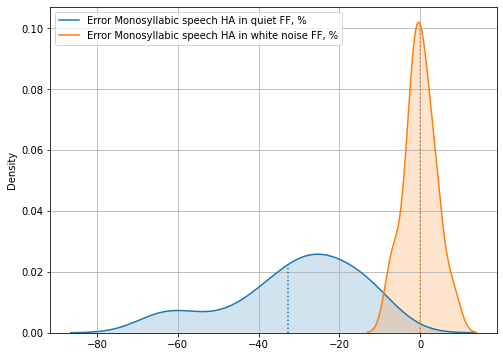

In [260]:
# plot_kde(df_res, ['Error ' + column_name1, 'Error ' + column_name2], figure_name='multi_mono.svg')
# plot_kde(df_res, ['Error ' + column_name1, 'Error ' + column_name2], figure_name='noise.svg')
plot_kde(df_res, ['Error ' + column_name1, 'Error ' + column_name2], figure_name='noise_mono.svg')